In [1]:
1+1

2

In [32]:
from langchain.chat_models import init_chat_model
import os

os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY") 
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")  


MODEL = "openai:gpt-4o-mini"
llm = init_chat_model(model=MODEL, temperature=0)

In [33]:
llm.invoke("hi")

2026-09-23 13:26:06,365 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a8bfe22efe', 'id': 'chatcmpl-ERHGmMd9zrX4ysU3QvDMpC2TveGBV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0ce71-d6a6-7410-9915-e8e86907263f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## document loader

In [2]:
from langchain_community.document_loaders import PyPDFDirectoryLoader,PyPDFLoader
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException

logging=log



class DocumentLoader:
    def __init__(self,directory:str,):
        self.directory=directory
        logging.info("initialized docuemnt loader")

    def document_loader(self):
        rew_documents=PyPDFDirectoryLoader(self.directory)
        self.docs=rew_documents.load()
        if self.docs:
            try:
                pdf_files = set()
                for doc in self.docs:
                    source = doc.metadata.get('source', 'unknown')
                    pdf_files.add(source)
                # Log each PDF file
                logging.info(f"✅ Successfully loaded {len(self.docs)}  , documents lent is  {len(pdf_files)} PDF files:")
                for pdf in pdf_files:
                    logging.info(f" 📄 {pdf}")
                
            except Exception as e:
                    logging.error(f"error in loading documents : {e}")
                    raise CustomException(
                        message=f"Failed to load documents {e}",
                        error_detail=e
                    )
        elif not self.docs:
            logging.error(f" No documents found in {self.directory}")
            print(f"⚠️ No documents found in {self.directory}")
         
        return self.docs
    





c:\dev\accountant_agent_v3\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = DocumentLoader("../data/")

2026-09-23 12:49:41,843 - INFO - initialized docuemnt loader


In [4]:
docs=data.document_loader()

2026-09-23 12:50:49,913 - INFO - ✅ Successfully loaded 1361  , documents lent is  6 PDF files:
2026-09-23 12:50:49,931 - INFO -  📄 ..\data\CGI\Code_impôts_2026.pdf
2026-09-23 12:50:49,932 - INFO -  📄 ..\data\PLAN_COMPTABLE\Plan_Comptable_marocain.pdf
2026-09-23 12:50:49,933 - INFO -  📄 ..\data\LOIS_DE_FINANCE\lois_de_finance_2026.pdf
2026-09-23 12:50:49,933 - INFO -  📄 ..\data\CGNC\code_generale_de_normalisation_comptable.pdf
2026-09-23 12:50:49,934 - INFO -  📄 ..\data\LOIS_DE_FINANCE\lois_de_finance_2025.pdf
2026-09-23 12:50:49,935 - INFO -  📄 ..\data\LOIS_DE_FINANCE\lois_de_finance_2024.pdf


In [5]:
docs[0].metadata

{'producer': 'Microsoft® Word 2016',
 'creator': 'Microsoft® Word 2016',
 'creationdate': '2025-12-30T13:12:54+01:00',
 'author': 'SADELLAH Ouiam',
 'moddate': '2025-12-30T13:12:54+01:00',
 'source': '..\\data\\CGI\\Code_impôts_2026.pdf',
 'total_pages': 765,
 'page': 0,
 'page_label': '1'}

In [6]:
docs[0].metadata.get("source")

'..\\data\\CGI\\Code_impôts_2026.pdf'

## embedings

In [7]:
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException
import sys

logging=log


class Embeddings:

    def __init__(self,
        model_name:str="sentence-transformers/all-MiniLM-L6-v2",
        device: str = "cpu",
        normalize_embeddings: bool = True,
        batch_size: int = 32):

        self.model_name = model_name
        self.device = device
        self.normalize_embeddings = normalize_embeddings
        self.batch_size = batch_size
        self._embeddings = None
        logging.info("embedding get initialized")


    def initializing_embedding(self):
        if self._embeddings is None:
            try:
                self.embeddings = HuggingFaceEmbeddings(
                        model_name=self.model_name,
                        model_kwargs={'device': self.device},
                        encode_kwargs={
                            'normalize_embeddings': self.normalize_embeddings,
                            'batch_size': self.batch_size
                        }
                    )
                log.info(f"initialiased embeding model {HuggingFaceEmbeddings.__class__.__name__} with model name : {self.model_name}")
            except Exception as e:
                    logging.error(f"error during initilizing embedings : {e}")
                    raise CustomException(
                        f"Failed to initialize embeddings with model {self.model_name} or their is an error in embeding models {e}",
                        sys
                    )
        return self.embeddings

## chunker

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker   # ← FIXED
from langchain_community.document_loaders import PyPDFDirectoryLoader
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException

logging=log



class TextSpliter:
    def __init__(self,embeding_model,persist_directory:str="vectorestore_VDB"):
        self.embeding=embeding_model
        self.persist_directory=persist_directory
        


    
    def split_documents(self,documents):
        # Split
        try:
            text_splitter = SemanticChunker(
                            embeddings=self.embeding,
                            breakpoint_threshold_type="percentile"
                        )

           
            chunks = text_splitter.split_documents(documents)
            logging.info(f"✅ Split {len(documents)} documents into {len(chunks)} chunks")
            return chunks
        except Exception as e:
            logging.error(f"❌ Error splitting documents: {e}")
            raise CustomException(f"Failed to chunk  {e}",sys)






## retriver

In [9]:
from langchain_chroma import Chroma
from src.loging.logger import log
from src.exceptions.custom_exceptions import CustomException

logging=log
from pathlib import Path

class VectorStore:
    def __init__(self, embeddings, persist_directory):
        self.embeddings = embeddings
        self.persist_directory = persist_directory
        self.vectorstore = None
        Path(persist_directory).mkdir(parents=True, exist_ok=True)
        logging.info(f"✅ VectorStore initialized with persist_dir: {persist_directory}")

    def create_from_documents(self, documents):
        """Create vectorstore from documents"""
        try:
            self.vectorstore = Chroma.from_documents(
                documents=documents,
                embedding=self.embeddings,
                persist_directory=self.persist_directory
            )
            logging.info(f"✅ Created vectorstore with {len(documents)} documents")
            return self.vectorstore
        except Exception as e:
            logging.error(f"❌ Error creating vectorstore: {e}")
            raise CustomException("Failed to create vectorstore", e)

    def load_existing(self):
        """Load existing vectorstore"""
        try:
            self.vectorstore = Chroma(
                embedding_function=self.embeddings,
                persist_directory=self.persist_directory
            )
            logging.info(f"✅ Loaded existing vectorstore from {self.persist_directory}")
            print(f"✅ Loaded existing vectorstore from {self.persist_directory}")
            return self.vectorstore
        except Exception as e:
            logging.error(f"❌ Error loading vectorstore: {e}")
            raise CustomException("Failed to load vectorstore", e)

    def get_retriever(self, k: int = 4):
        """Get retriever from vectorstore"""
        if self.vectorstore is None:
            raise CustomException("Vectorstore not created yet. Call create_from_documents first.")
        return self.vectorstore.as_retriever(search_type="mmr",
                                             search_kwargs={"k": k,
                                                            "fetch_k": 20,
                                                            "lambda_mult": 0.5 })

In [10]:
data = DocumentLoader("../data/PLAN_COMPTABLE")
docs=data.document_loader()
embeding_model=Embeddings()
embeding=embeding_model.initializing_embedding()
text_splietr=TextSpliter(embeding)
chunks=text_splietr.split_documents(docs)
vectore_store=VectorStore(embeding,"artifacts/vectorestore/CGI")
vectore_store.create_from_documents(chunks)
store=vectore_store.get_retriever()

2026-09-23 12:50:51,265 - INFO - initialized docuemnt loader
2026-09-23 12:50:53,989 - INFO - ✅ Successfully loaded 24  , documents lent is  1 PDF files:
2026-09-23 12:50:53,990 - INFO -  📄 ..\data\PLAN_COMPTABLE\Plan_Comptable_marocain.pdf
2026-09-23 12:50:53,994 - INFO - embedding get initialized
2026-09-23 12:50:54,520 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-09-23 12:50:54,522 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-23 12:50:54,580 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2Fmodules.json=&etag=%22952a9b81c0bfd99800fabf352f69c7ccd46c5e43%22 "HTTP/1.1 200 OK"
2026-09-23 1

In [11]:
print(chunks[2].page_content)

16 COMPTES DE LIAISON DES ETABLISSEMENTS ET SUCCURSALES 
160 Comptes de liaison des établissements et succursales 
1601 Comptes de liaison du siège 
1605 Comptes de liaison des établissements 
17 Ecarts de conversion - Passif 
171 Augmentation des créances immobilisées 
1710 Augmentation des créances immobilisées 
172 Diminution des dettes de financement 
1720 Diminution des dettes de financement 
 
 
 
 
CLASSE 2 : COMPTES D'ACTIF IMMOBILISE 
 
21 IMMOBILISATIONS EN NON-VALEURS 
211 Frais préliminaires 
2111 Frais de constitution 
2112 Frais préalables au démarrage 
2113 Frais d'augmentation du capital 
2114 Frais sur opérations de fusions, scissions et transformations 
2116 Frais de prospection 
2117 Frais de publicité 
2118 Autres frais préliminaires 
212 Charges à répartir sur plusieurs exercices 
2121 Frais d'acquisitition des immobilisations 
2125 Frais d'émission des emprunts 
2128 Autres charges à répartir 
213 Primes de remboursement des obligations 
2130 Primes de rembourseme

In [12]:
store.invoke("tva recuperable sur charge")

[Document(id='d6f18563-03b6-42c6-aa13-7293daab8598', metadata={'moddate': '2021-02-16T14:31:31+00:00', 'producer': 'www.ilovepdf.com', 'creationdate': '2021-02-16T14:31:27+00:00', 'page': 2, 'total_pages': 24, 'title': 'Plan cptable Maroc.PDF', 'author': 'Pierre', 'creator': 'Microsoft® Word 2016', 'source': '..\\data\\PLAN_COMPTABLE\\Plan_Comptable_marocain.pdf', 'page_label': '3'}, page_content="16 COMPTES DE LIAISON DES ETABLISSEMENTS ET SUCCURSALES \n160 Comptes de liaison des établissements et succursales \n1601 Comptes de liaison du siège \n1605 Comptes de liaison des établissements \n17 Ecarts de conversion - Passif \n171 Augmentation des créances immobilisées \n1710 Augmentation des créances immobilisées \n172 Diminution des dettes de financement \n1720 Diminution des dettes de financement \n \n \n \n \nCLASSE 2 : COMPTES D'ACTIF IMMOBILISE \n \n21 IMMOBILISATIONS EN NON-VALEURS \n211 Frais préliminaires \n2111 Frais de constitution \n2112 Frais préalables au démarrage \n2113 F

In [13]:
from src.PipeLine.pipeline import  RagPipeLine

In [ ]:
pipeline=RagPipeLine(data_dir="../data/PLAN_COMPTABLE",persist_dir="artifacts/vectorestore/plan_comptable",force_rebuild=False)

In [ ]:
pip=pipeline.run()

In [ ]:
result=pip.invoke("les cadaux publicitaire dans  IR")
for i in range(len(result)):
    print(result[i].page_content)
    print("___________________________________________")

In [ ]:
result

In [14]:
from src.tools.plan_comptable import plan_comptable_tool
from src.tools.cgnc import cgnc_tool
from src.tools.finance_law import finance_law_tool
from src.tools.tax import CGI_tool
from src.tools.web_search_tool import search

2026-09-23 12:52:37,476 - INFO - embedding get initialized



🚀 RAG Pipeline initialized
📂 Data: ./data/PLAN_COMPTABLE
💾 Persist: artifacts/vectorestore/db_plan_comptable
🔍 Vectorstore exists: True



2026-09-23 12:52:38,660 - INFO - initialiased embeding model OpenAIEmbeddings with model name : text-embedding-3-large
2026-09-23 12:52:38,661 - INFO - ✅ VectorStore initialized with persist_dir: artifacts/vectorestore/db_plan_comptable
2026-09-23 12:52:38,680 - INFO - ✅ Loaded Chroma from artifacts/vectorestore/db_plan_comptable
2026-09-23 12:52:38,686 - INFO - ✅ Loaded BM25 index from artifacts\vectorestore\db_plan_comptable\bm25_index.pkl
2026-09-23 12:52:38,687 - INFO - ✅ Hybrid retriever restored
2026-09-23 12:52:38,690 - INFO - embedding get initialized
2026-09-23 12:52:38,712 - INFO - initialiased embeding model OpenAIEmbeddings with model name : text-embedding-3-large
2026-09-23 12:52:38,712 - INFO - ✅ VectorStore initialized with persist_dir: artifacts/vectorestore/db_CGNC
2026-09-23 12:52:38,738 - INFO - ✅ Loaded Chroma from artifacts/vectorestore/db_CGNC
2026-09-23 12:52:38,753 - INFO - ✅ Loaded BM25 index from artifacts\vectorestore\db_CGNC\bm25_index.pkl
2026-09-23 12:52:3

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from artifacts/vectorestore/db_plan_comptable

🚀 RAG Pipeline initialized
📂 Data: ./data/CGNC
💾 Persist: artifacts/vectorestore/db_CGNC
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from artifacts/vectorestore/db_CGNC

🚀 RAG Pipeline initialized
📂 Data: ./data/LOIS_DE_FINANCE
💾 Persist: artifacts/vectorestore/LOIS_DE_FINANCE
🔍 Vectorstore exists: True

🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from artifacts/vectorestore/LOIS_DE_FINANCE

🚀 RAG Pipeline initialized
📂 Data: ./data/CGI
💾 Persist: artifacts/vectorestore/db_CGI
🔍 Vectorstore exists: True



2026-09-23 12:52:38,849 - INFO - ✅ VectorStore initialized with persist_dir: artifacts/vectorestore/db_CGI
2026-09-23 12:52:38,869 - INFO - ✅ Loaded Chroma from artifacts/vectorestore/db_CGI
2026-09-23 12:52:38,912 - INFO - ✅ Loaded BM25 index from artifacts\vectorestore\db_CGI\bm25_index.pkl
2026-09-23 12:52:38,913 - INFO - ✅ Hybrid retriever restored


🔄 Loading existing vectorstore...
✅ Loaded existing vectorstore from artifacts/vectorestore/db_CGI


In [15]:
tools=[cgnc_tool,finance_law_tool,CGI_tool,plan_comptable_tool,search]

In [16]:
from  dotenv import  load_dotenv

from langchain_openrouter import ChatOpenRouter
import os

import os

load_dotenv()


os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")  

MODEL = "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free"
llm = ChatOpenRouter(model=MODEL)

In [17]:
llm.invoke("what is todays date")

2026-09-23 12:52:40,425 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


AIMessage(content="Today's date is November\u202f3,\u202f2025.", additional_kwargs={'reasoning_content': 'The user asks "what is todays date". The system date is provided: 2025-11-03. So answer: November 3, 2025. Provide concise answer.\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user asks "what is todays date". The system date is provided: 2025-11-03. So answer: November 3, 2025. Provide concise answer.\n'}]}, response_metadata={'model_name': 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free', 'id': 'gen-1790167942-LS6BFt2uvg7EQfQuXdHH', 'created': 1790167942, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--01a0ce53-478a-74e1-912a-4825e48d9b49-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 62, 'total_tokens': 83, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 3

In [18]:
llm_with_tools=llm.bind_tools(tools, tool_choice="any")

In [20]:
llm_with_tools

_ChatModelBinding(bound=ChatOpenRouter(output_version=None, profile={'name': 'Nemotron 3 Nano Omni (free)', 'release_date': '2026-04-28', 'last_updated': '2026-04-28', 'open_weights': True, 'max_input_tokens': 256000, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True}, client=<openrouter.sdk.OpenRouter object at 0x00000253D67C0410>, openrouter_api_key=SecretStr('**********'), openrouter_api_base=None, app_url='https://docs.langchain.com', app_title='LangChain', model_name='nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free', model_kwargs={}, session_id=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'cgnc_maroc', 'description': 'Moroccan accounting standards: CGNC rules, financial statements (bilan

In [ ]:
result=llm_with_tools.invoke("what is tva recuperable sur charge ")
print(result)

In [23]:
CHAT_PROMPT = """You are a Moroccan accounting and tax assistant.
You MUST always use a tool. NEVER answer from memory.

Tool routing rules:
1. Account number needed → plan_comptable_marocain
2. Accounting rule or principle → cgnc_maroc
3. Permanent tax rate or tax law → cgi_maroc
4. Recent/annual tax change + year mentioned → loi_finances_maroc
5. Current news, exchange rates, outside info → google_search

NEVER invent article numbers or account codes."""


STRUCTURING_PROMPT = """You are a Moroccan accounting and tax assistant.
You received tool results. Now produce a clear, structured final answer in the same language as the user.

Rules:
- Cite the source tool used
- Use tables for journal entries (Débit / Crédit / Montant)
- If the tool result doesn't contain the answer, say so explicitly
- NEVER invent article numbers, account codes, or tax rates not present in the retrieved text"""


In [40]:
from langchain_core.messages import AIMessage, HumanMessage,SystemMessage

from langgraph.graph import StateGraph, START, END 
from  langgraph.prebuilt import ToolNode
from typing import TypedDict,List
from typing_extensions import Annotated
from langgraph.graph import add_messages

from  dotenv import  load_dotenv

from langchain_openrouter import ChatOpenRouter
import os

import os

os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")  

MODEL = "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free"
llm = ChatOpenRouter(model=MODEL)


llm_with_tools=llm.bind_tools(tools)



class AgentState(TypedDict):
    messages:Annotated[List,add_messages]

def chat_node(state: AgentState) -> dict:
    system_message = SystemMessage(content=CHAT_PROMPT)
    all_messages = [system_message] + state["messages"]
    response = llm_with_tools.invoke(all_messages)
    return {"messages": [response]}

tool_node=ToolNode(tools)

def agent_structuring_response(state: AgentState):
    # Find the last ToolMessage to know which tool was used
    
    system_message = SystemMessage(content=STRUCTURING_PROMPT)

    all_messages = [system_message] + state["messages"][-5:]
    return {"messages": [llm_with_tools.invoke(all_messages)]}


from langgraph.prebuilt import tools_condition



# ── Build the graph ──
builder = StateGraph(AgentState)
builder.add_node("chat", chat_node)
builder.add_node("tool_node", tool_node)
#builder.add_node("structures", agent_structuring_response)


builder.add_edge(START, "chat")
builder.add_conditional_edges(
    "chat",
    tools_condition,
    {
        "tools": "tool_node",
        "__end__": END
    }
)
builder.add_edge("tool_node", "chat")


#builder.add_edge("structures", END)



graph = builder.compile()



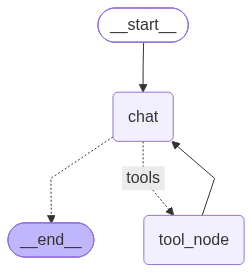

In [41]:
graph

In [28]:
# ── Invoke ──
result = graph.invoke({"messages": [HumanMessage(content="COMMENT COMPTABILISE LES OPERATION ON DEVISE ? UN EXEPMLE DE UN ACHAT DE MATERIEL DE TRANSPORT POUR 20000 USD en  23 MAY 2026 moitier ent in same date et le moitier en 01/03/0227 ")]})
result["messages"]

2026-09-23 13:19:52,038 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-09-23 13:20:42,075 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-09-23 13:20:42,849 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
2026-09-23 13:20:43,349 - INFO - HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


ResponseValidationError: Response validation failed: 5 validation errors for Unmarshaller
body.choices
  Field required [type=missing, input_value={'id': 'gen-1790169625-jM...provider_unavailable'}}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
body.created
  Field required [type=missing, input_value={'id': 'gen-1790169625-jM...provider_unavailable'}}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
body.model
  Field required [type=missing, input_value={'id': 'gen-1790169625-jM...provider_unavailable'}}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
body.object
  Field required [type=missing, input_value={'id': 'gen-1790169625-jM...provider_unavailable'}}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
body.system_fingerprint
  Field required [type=missing, input_value={'id': 'gen-1790169625-jM

In [9]:
import pprint

x=result["messages"][-1].content
pprint.pprint(x)

('**Conversion en dirham d’un actif immobilisé acquis en monnaie étrangère – '
 'traitement selon le PCG marocain (CGNC)**  \n'
 '\n'
 '| Étape | Comptabilisation | Comptes utilisés (exemple) | Explication |\n'
 '|-------|------------------|----------------------------|-------------|\n'
 '| **1.\u202fAcquisition (date d’entrée)** | Conversion du coût en devise '
 'étrangère au **taux de change du jour de l’opération** (date de facturation, '
 'de l’accord ou de paiement). | • Débit du compte d’immobilisation concerné '
 '(classe\u202f23) –\u202fex.\u202f2321\u202f«\u202fBâtiments\u202f», '
 '2332\u202f«\u202fMatériel et outillage\u202f», 2340\u202f«\u202fMatériel de '
 'transport\u202f», etc.<br>• Crédit du compte de paiement ou de dette '
 '(ex.\u202f5141\u202f«\u202fBanque\u202f», 4411\u202f«\u202fFournisseurs\u202f'
 '») pour le montant en dirhams obtenu. | L’actif est inscrit à sa **valeur '
 'd’entrée historique** (coût en dirhams au taux du jour d’entrée). Aucune '
 'réévaluation

In [2]:
hasattr("4A","A")

False

## OCR Unlimited

In [ ]:
import os
import torch
from transformers import AutoModel, AutoTokenizer

model_name = 'baidu/Unlimited-OCR'

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_name,
    trust_remote_code=True,
    use_safetensors=True,
    torch_dtype=torch.bfloat16,
)
model = model.eval().cuda()

c:\dev\accountant_agent_v3\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
# ── Single image supports two configs: gundam or base ──
# gundam: base_size=1024, image_size=640, crop_mode=True
# base: base_size=1024, image_size=1024, crop_mode=False
model.infer(
    tokenizer,
    prompt='<image>document parsing.',
    image_file='test_img.png',
    output_path='your/output/dir',
    base_size=1024, image_size=640, crop_mode=True,
    max_length=32768,
    no_repeat_ngram_size=35, ngram_window=128,
    save_results=True,
)

#

In [ ]:
# ── Multi page / PDF only uses base (image_size=1024) ──
model.infer_multi(
    tokenizer,
    prompt='<image>Multi page parsing.',
    image_files=['page1.png', 'page2.png', 'page3.png'],
    output_path='your/output/dir',
    image_size=1024,
    max_length=32768,
    no_repeat_ngram_size=35, ngram_window=1024,
    save_results=True,
)



In [ ]:
# ── PDF (convert pages to images, then multi-page parsing) ──
import tempfile, fitz  # PyMuPDF

def pdf_to_images(pdf_path, dpi=300):
    doc = fitz.open(pdf_path)
    tmp_dir = tempfile.mkdtemp(prefix='pdf_ocr_')
    mat = fitz.Matrix(dpi / 72, dpi / 72)
    paths = []
    for i, page in enumerate(doc):
        out = os.path.join(tmp_dir, f'page_{i+1:04d}.png')
        page.get_pixmap(matrix=mat).save(out)
        paths.append(out)
    doc.close()
    return paths



In [ ]:
model.infer_multi(
    tokenizer,
    prompt='<image>Multi page parsing.',
    image_files=pdf_to_images('your_doc.pdf', dpi=300),
    output_path='your/output/dir',
    image_size=1024,
    max_length=32768,
    no_repeat_ngram_size=35, ngram_window=1024,
    save_results=True,
)


## GLM OCR

In [ ]:
from transformers import AutoProcessor, GlmOcrForConditionalGeneration

model_id = "zai-org/GLM-OCR"

# Load processor
processor = AutoProcessor.from_pretrained(model_id)

# Load model
model = GlmOcrForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
)

c:\dev\accountant_agent_v3\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\dev\accountant_agent_v3\env\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\VICTUS\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://do

In [3]:
# Your image + OCR instruction
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": "test1.png"},
            {"type": "text", "text": "Text Recognition:"},
        ],
    }
]

# Convert message into model inputs
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

# Generate OCR result
output = model.generate(
    **inputs,
    max_new_tokens=512
)

# Decode result
text = processor.decode(
    output[0],
    skip_special_tokens=True
)

print(text)


<|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|><|image|>

## LightOnOCR-2

In [ ]:
# instalation 
# vllm serve lightonai/LightOnOCR-2-1B \
#    --limit-mm-per-prompt '{"image": 1}' --mm-processor-cache-gb 0 --no-enable-prefix-caching

# uv pip install transformers # => 5.0.0
# uv pip install pillow pypdfium2


In [ ]:
import torch
from transformers import LightOnOcrForConditionalGeneration, LightOnOcrProcessor

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32 if device == "mps" else torch.bfloat16

model = LightOnOcrForConditionalGeneration.from_pretrained("lightonai/LightOnOCR-2-1B", torch_dtype=dtype).to(device)
processor = LightOnOcrProcessor.from_pretrained("lightonai/LightOnOCR-2-1B")

url = "https://huggingface.co/datasets/hf-internal-testing/fixtures_ocr/resolve/main/SROIE-receipt.jpeg"

conversation = [{"role": "user", "content": [{"type": "image", "url": url}]}]

inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)
inputs = {k: v.to(device=device, dtype=dtype) if v.is_floating_point() else v.to(device) for k, v in inputs.items()}

output_ids = model.generate(**inputs, max_new_tokens=1024)
generated_ids = output_ids[0, inputs["input_ids"].shape[1]:]
output_text = processor.decode(generated_ids, skip_special_tokens=True)
print(output_text)


In [ ]:
import base64
import requests
import pypdfium2 as pdfium
import io

ENDPOINT = "http://localhost:8000/v1/chat/completions"
MODEL = "lightonai/LightOnOCR-2-1B"

# Download PDF from arXiv
pdf_url = "https://arxiv.org/pdf/2412.13663"
pdf_data = requests.get(pdf_url).content

# Open PDF and convert first page to image
pdf = pdfium.PdfDocument(pdf_data)
page = pdf[0]
# Render at 200 DPI (scale factor = 200/72 ≈ 2.77)
pil_image = page.render(scale=2.77).to_pil()

# Convert to base64
buffer = io.BytesIO()
pil_image.save(buffer, format="PNG")
image_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')

# Make request
payload = {
    "model": MODEL,
    "messages": [{
        "role": "user",
        "content": [{
            "type": "image_url",
            "image_url": {"url": f"data:image/png;base64,{image_base64}"}
        }]
    }],
    "max_tokens": 4096,
    "temperature": 0.2,
    "top_p": 0.9,
}

response = requests.post(ENDPOINT, json=payload)
text = response.json()['choices'][0]['message']['content']
print(text)
